In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [4]:
data = pd.read_csv('used_cars.csv')

In [5]:
data

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


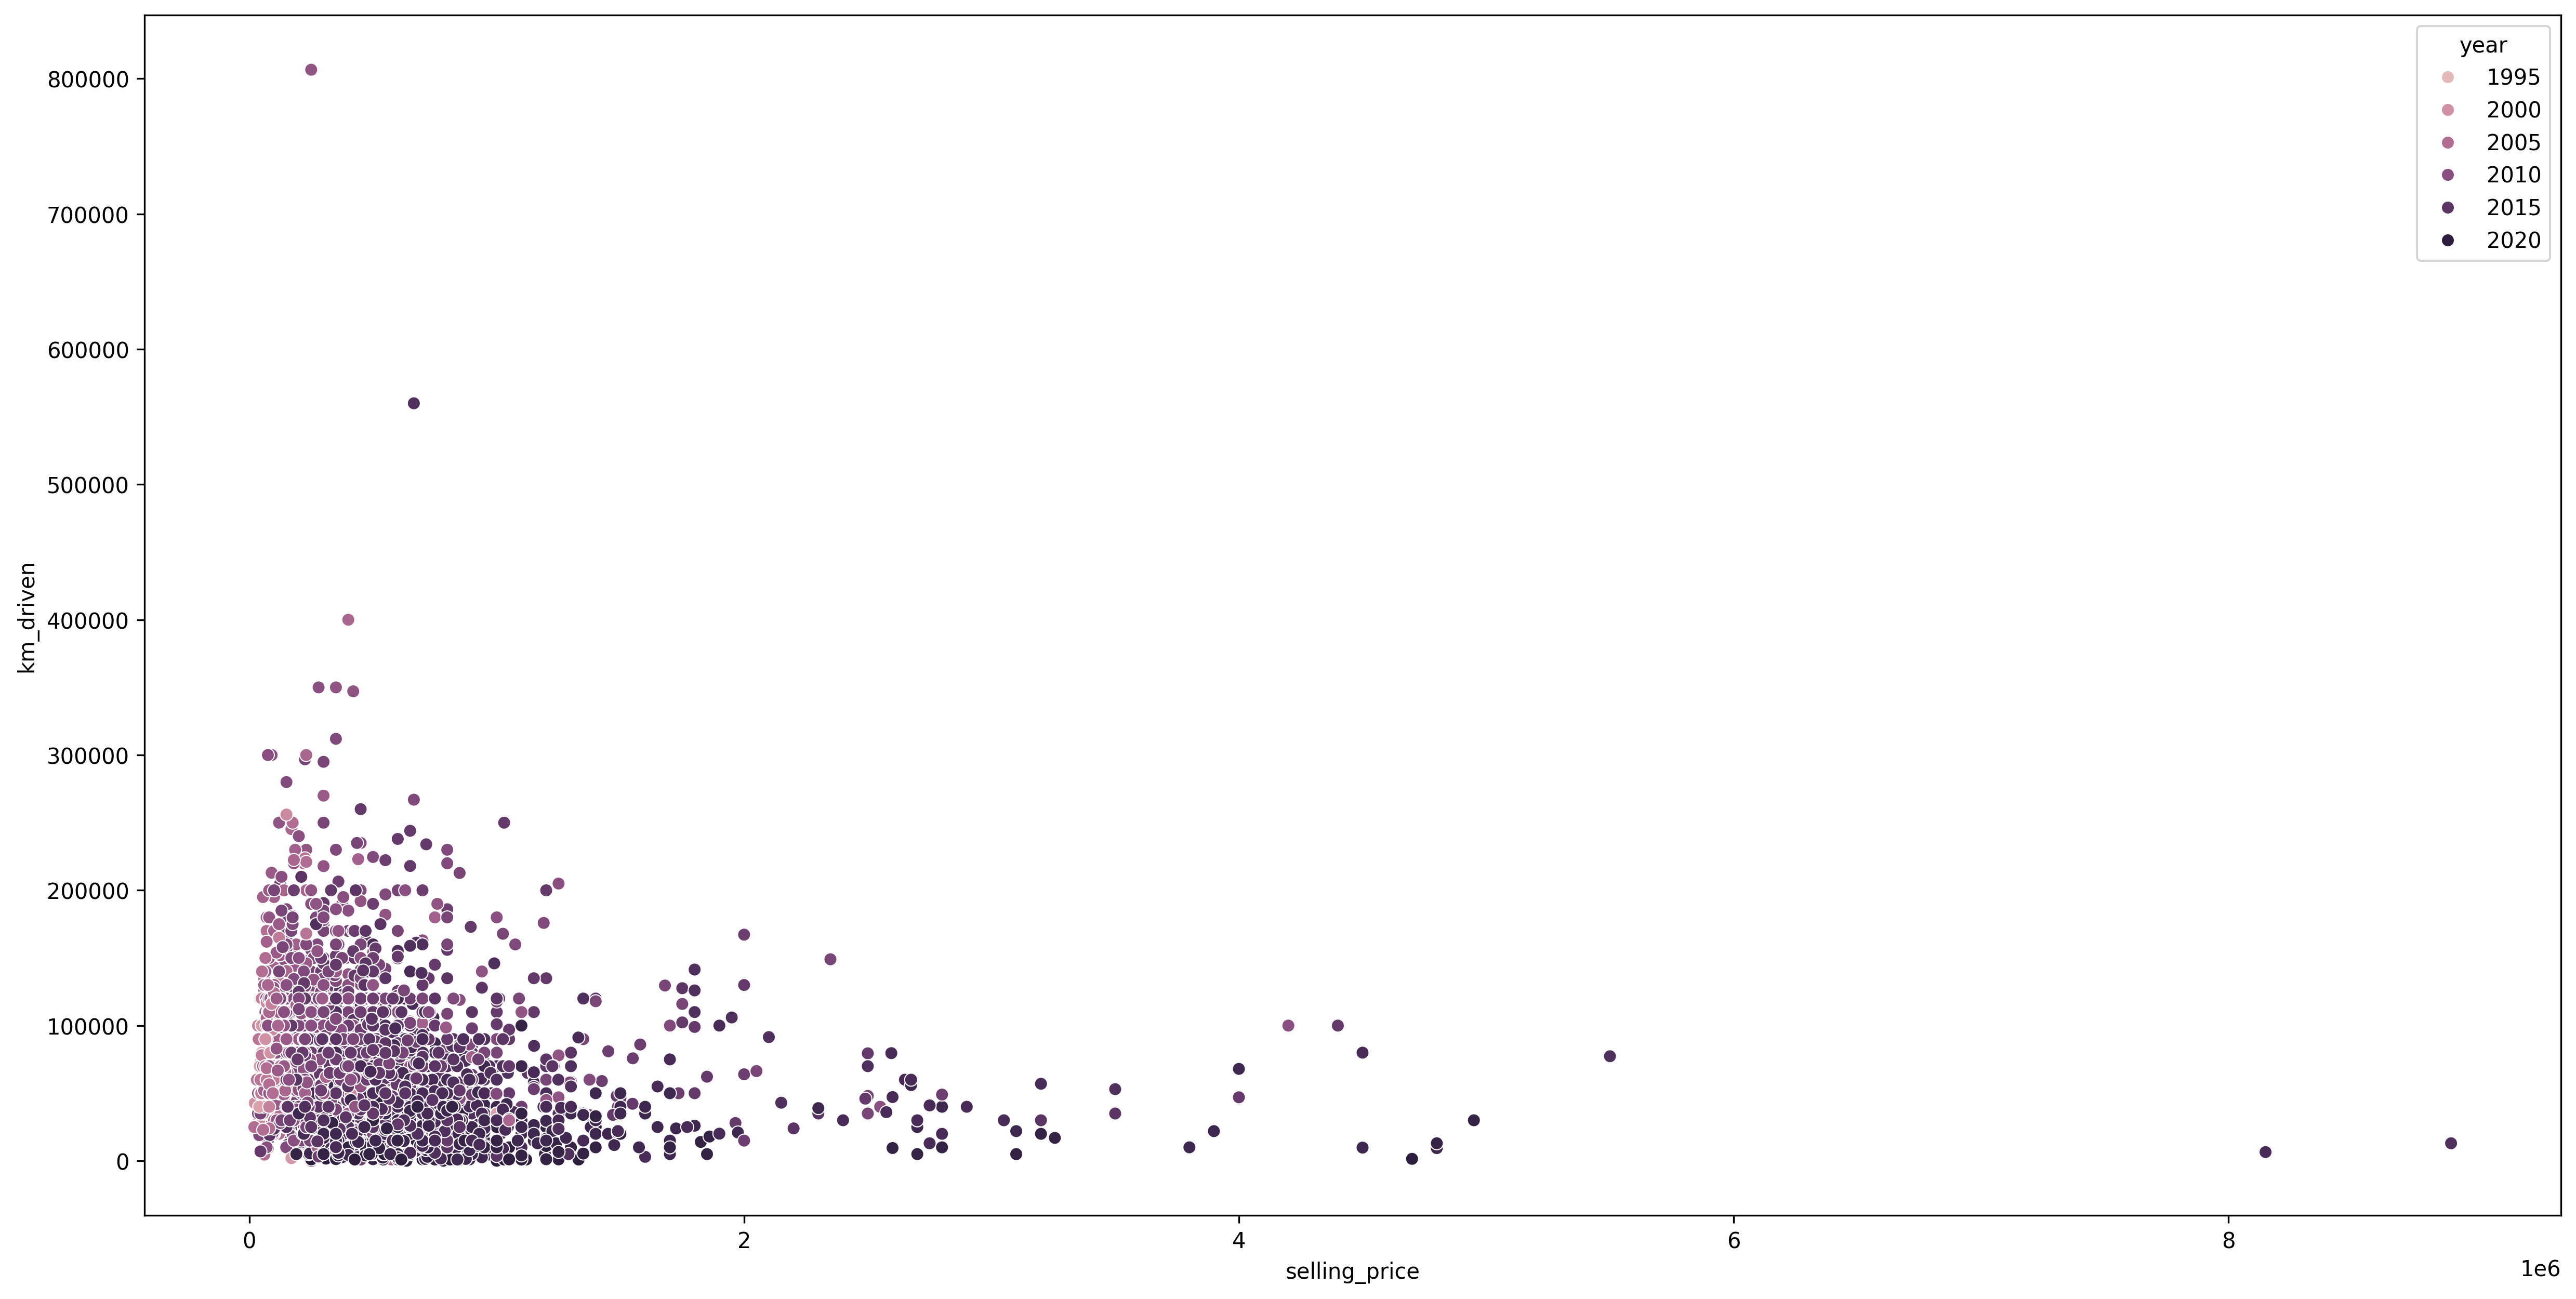

In [6]:
plt.figure(figsize=(20,10), dpi=300)
sns.scatterplot(data=data, x=data['selling_price'], y=data['km_driven'], hue=data['year'])
plt.show()

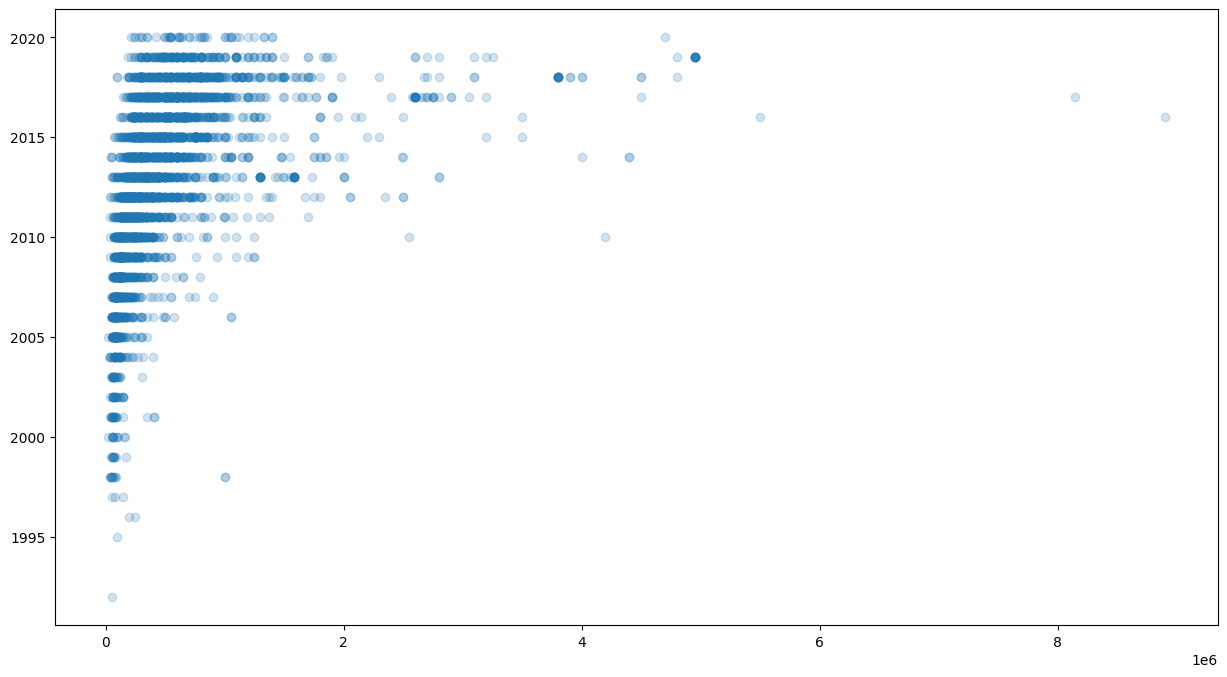

In [7]:
plt.figure(figsize=(15,8))
plt.scatter(x=data['selling_price'], y=data['year'], alpha=0.2)
plt.show()

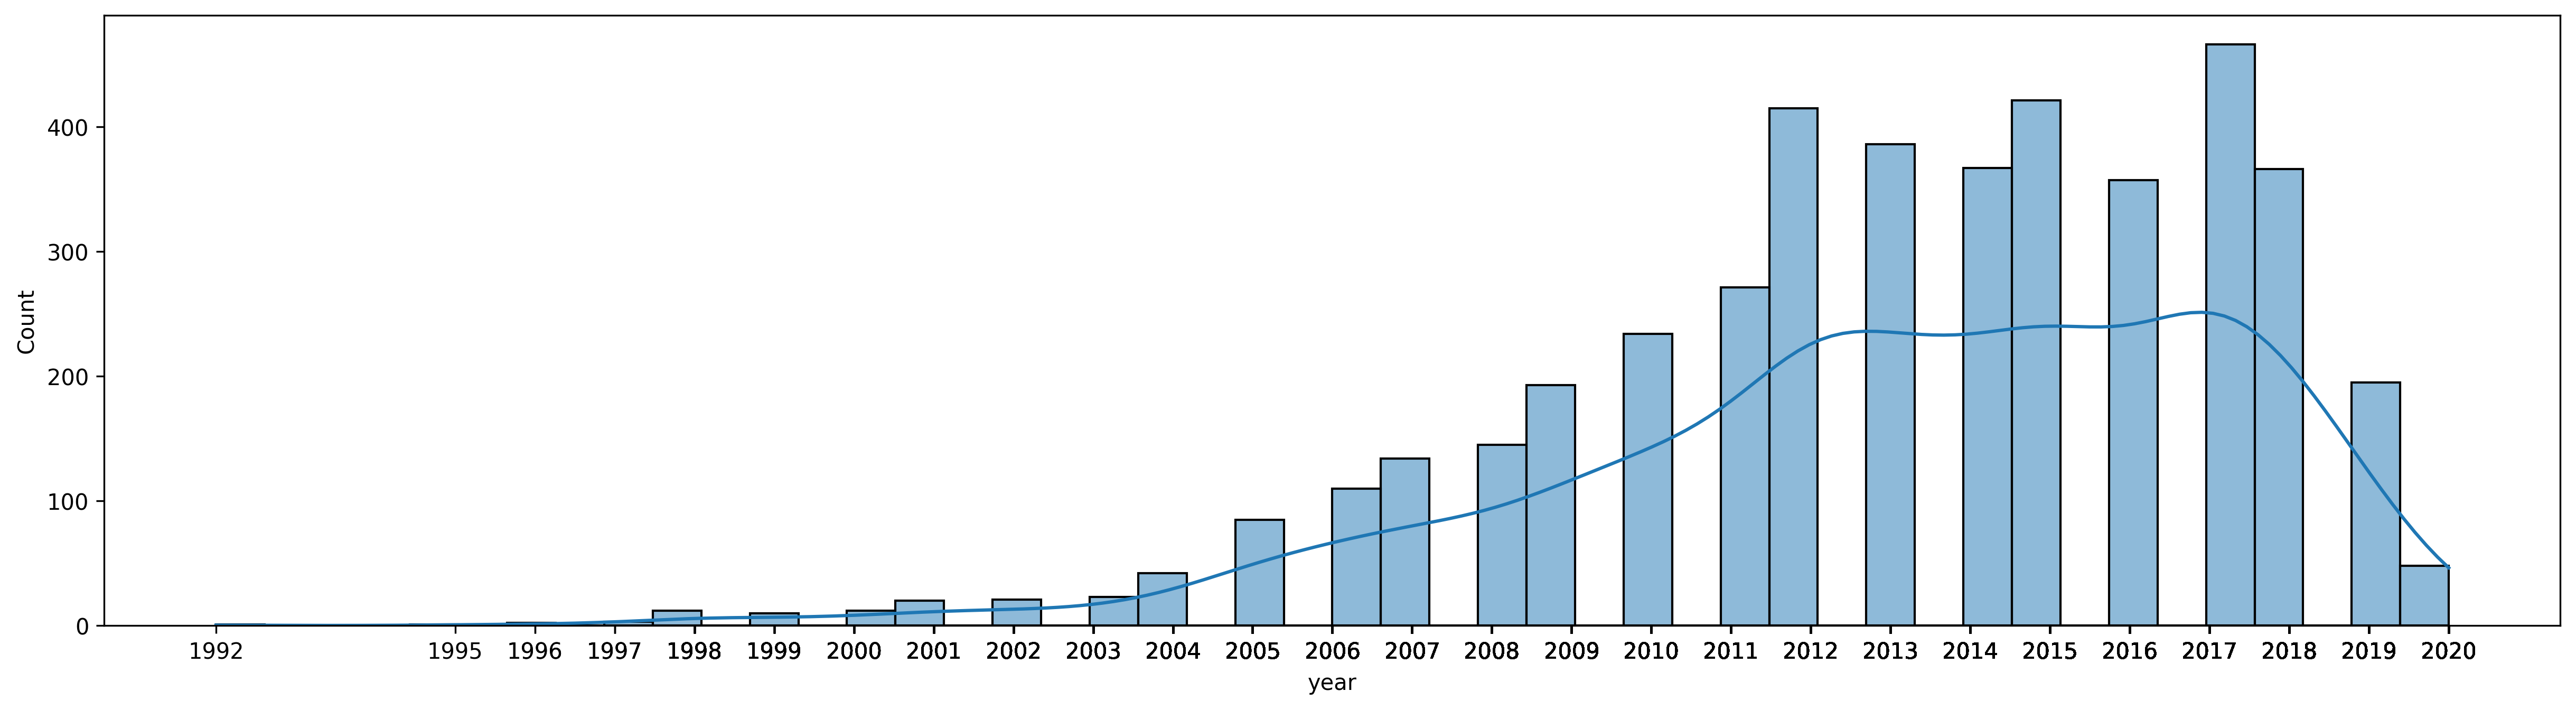

In [8]:
plt.figure(figsize=(20,5), dpi=300)
sns.histplot(data=data, x='year', kde=True)
plt.xticks(data['year'])
plt.show()

In [9]:
df = data

In [10]:
df.select_dtypes(include=['int64', 'float64']).corr()

,year,selling_price,km_driven
year,1.000000,0.413922,-0.419688
selling_price,0.413922,1.000000,-0.192289
km_driven,-0.419688,-0.192289,1.000000


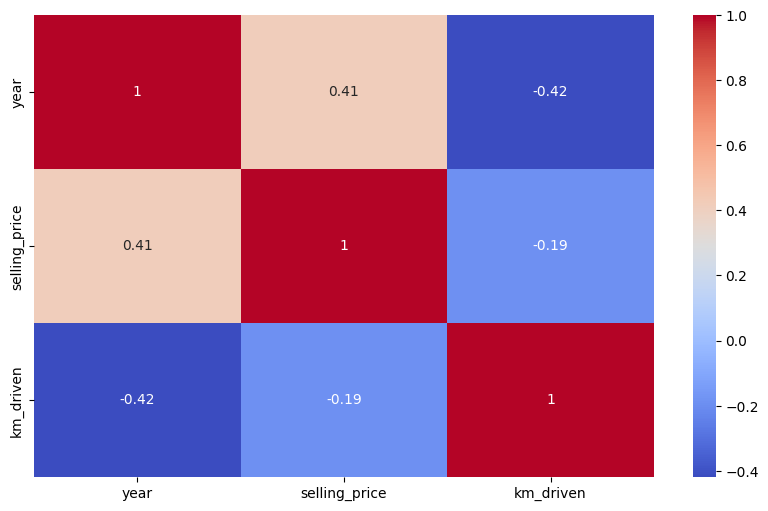

In [11]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [12]:
df['brand'] = df['name'].str.split().str[0]

In [13]:
df['brand']

,brand
0,Maruti
1,Maruti
2,Hyundai
3,Datsun
4,Honda
...,...
4335,Hyundai
4336,Hyundai
4337,Maruti
4338,Hyundai


In [14]:
df_encoded = pd.get_dummies(
    df,
    columns=['brand', 'fuel', 'seller_type', 'transmission', 'owner'],
    drop_first=True
)

In [15]:
df_encoded

,name,year,selling_price,km_driven,brand_Audi,brand_BMW,brand_Chevrolet,brand_Daewoo,brand_Datsun,brand_Fiat,...,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti 800 AC,2007,60000,70000,False,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
1,Maruti Wagon R LXI Minor,2007,135000,50000,False,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
2,Hyundai Verna 1.6 SX,2012,600000,100000,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
3,Datsun RediGO T Option,2017,250000,46000,False,False,False,False,True,False,...,False,False,True,True,False,True,False,False,False,False
4,Honda Amaze VX i-DTEC,2014,450000,141000,False,False,False,False,False,False,...,False,False,False,True,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,False,False,False,False,False,False,...,False,False,False,True,False,True,False,True,False,False
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,False,False,False,False,False,False,...,False,False,False,True,False,True,False,True,False,False
4337,Maruti 800 AC BSIII,2009,110000,83000,False,False,False,False,False,False,...,False,False,True,True,False,True,False,True,False,False
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False


In [16]:
encoded_corr = df_encoded.select_dtypes(include=['int64', 'float64', 'bool']).corr()
encoded_corr['selling_price'].sort_values(ascending=False)

,selling_price
selling_price,1.000000
year,0.413922
brand_BMW,0.401857
brand_Mercedes-Benz,0.354215
brand_Audi,0.292174
fuel_Diesel,0.282947
brand_Land,0.182329
brand_Toyota,0.162161
seller_type_Trustmark Dealer,0.110176
brand_Volvo,0.107745


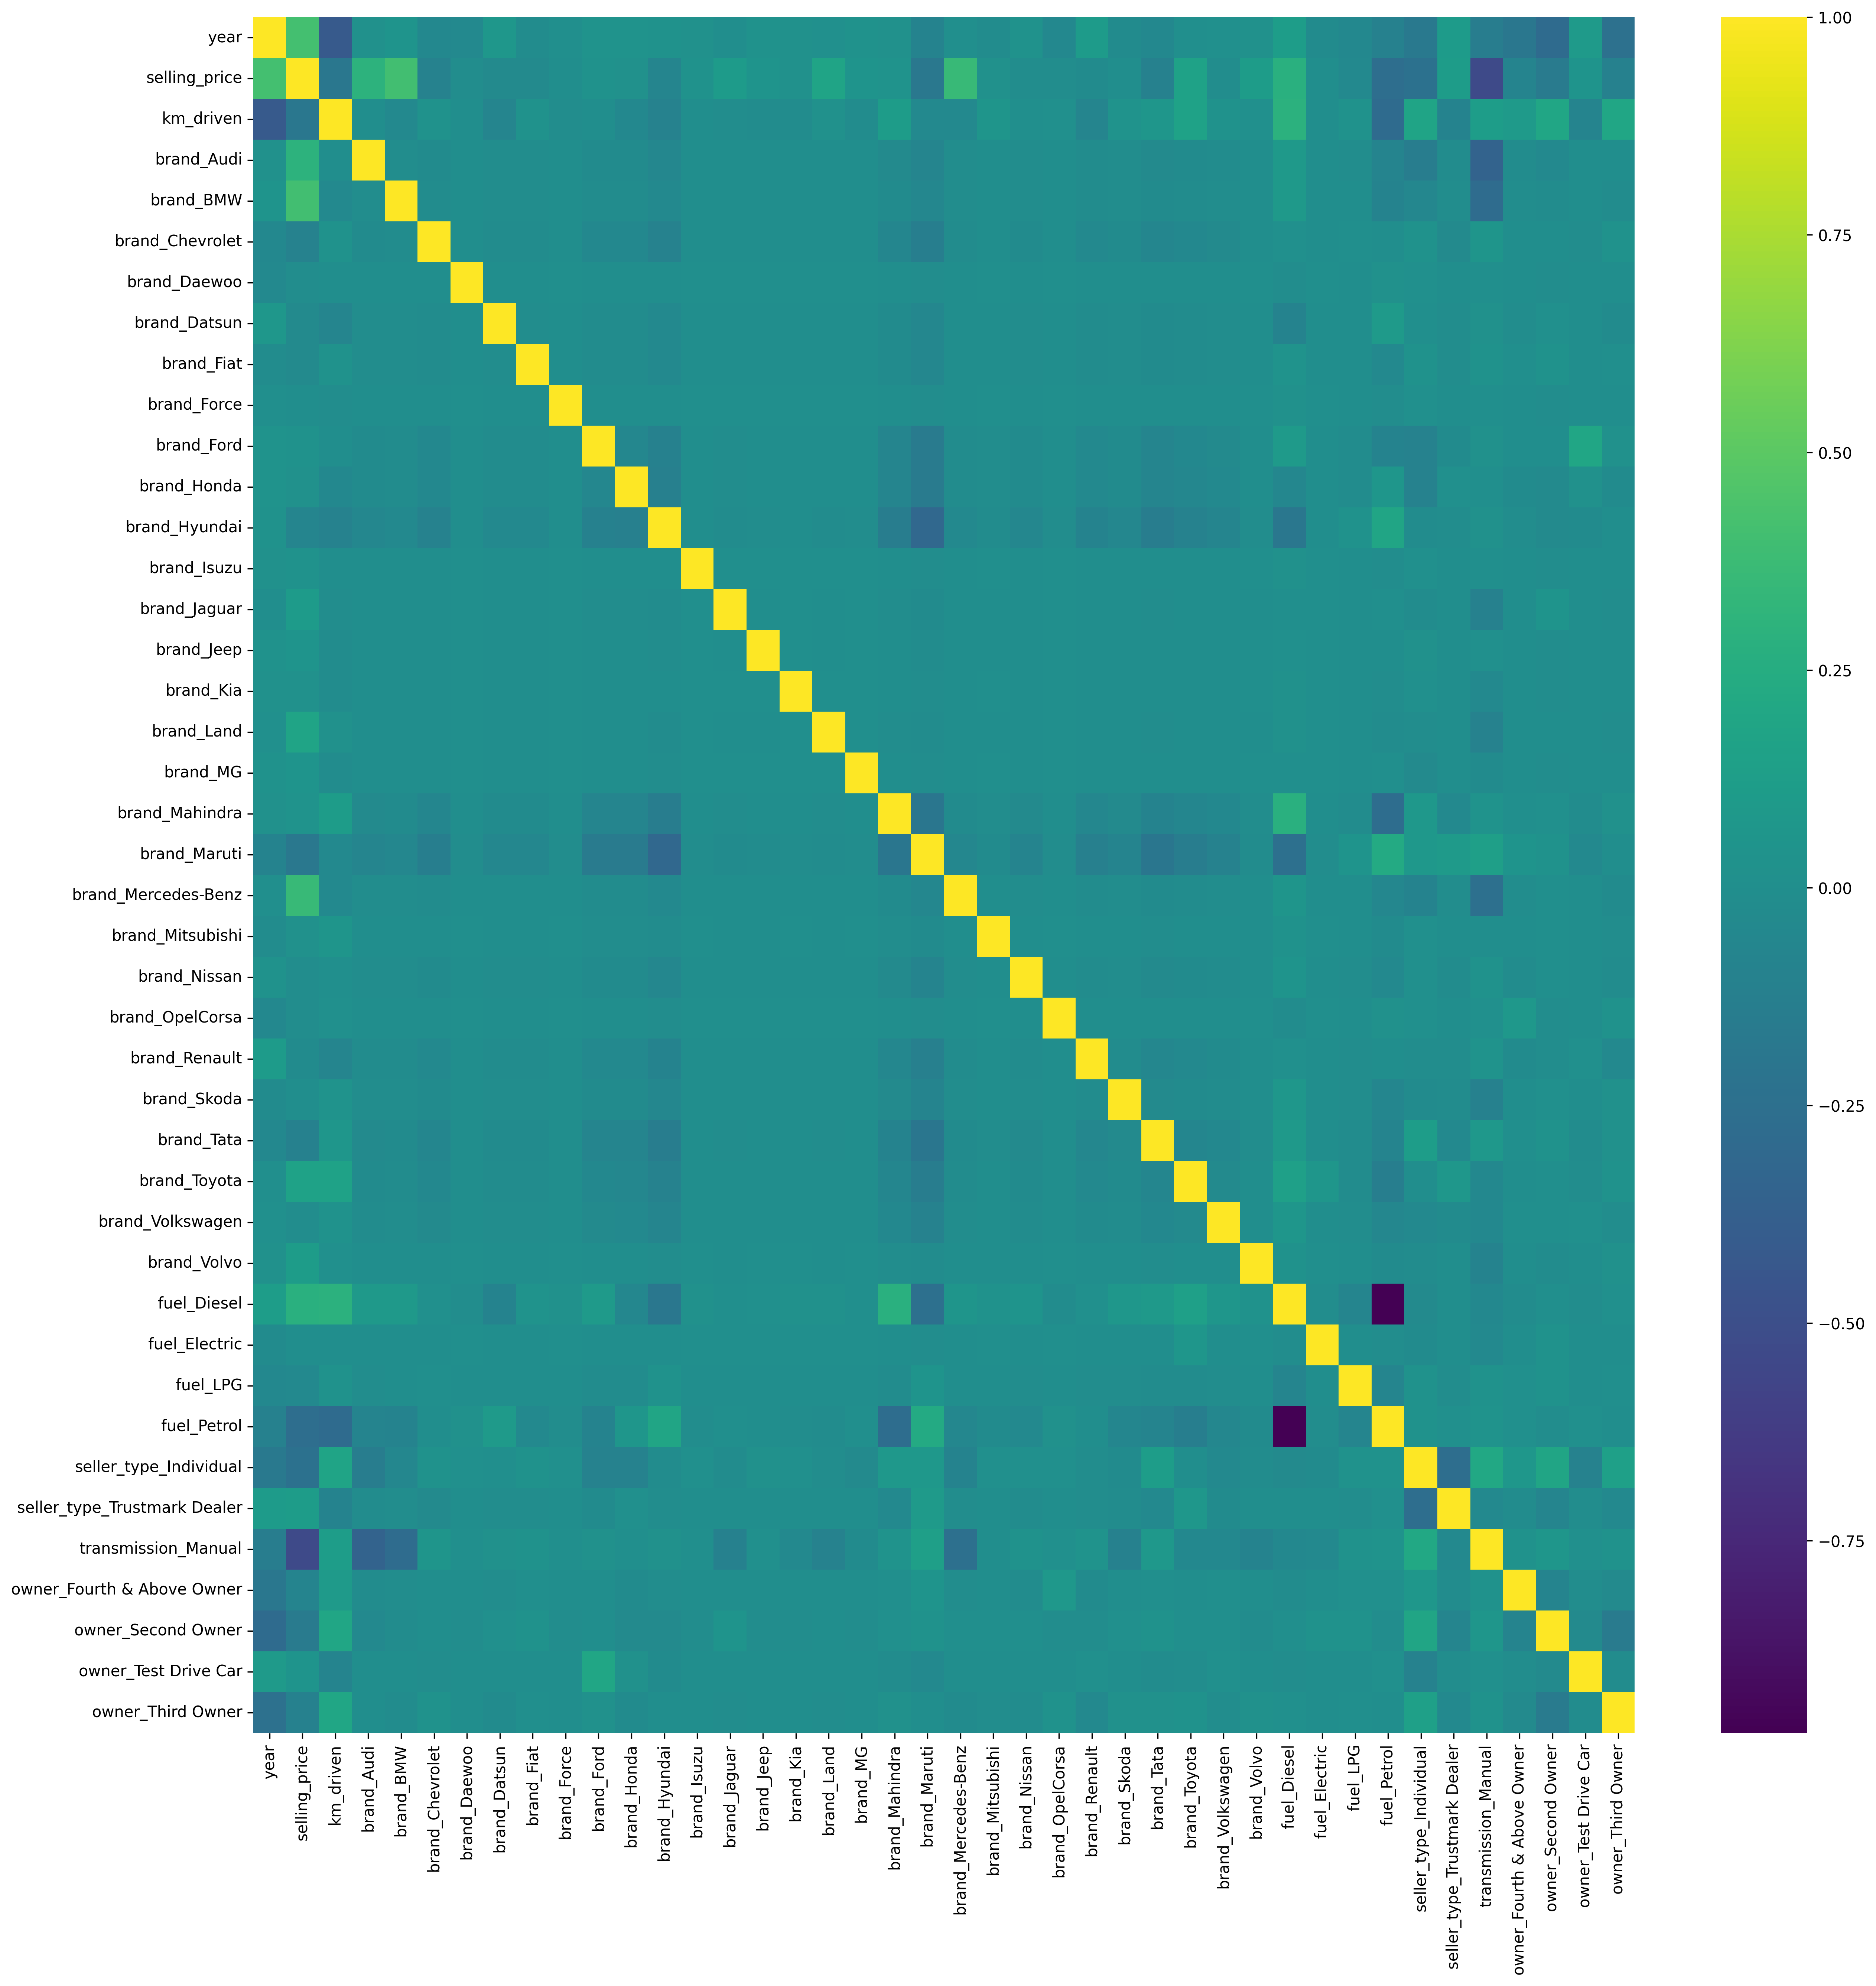

In [17]:
plt.figure(figsize=(20, 20), dpi=300)
sns.heatmap(encoded_corr, cmap='viridis')
plt.show()

# **Training and testing split**

In [18]:
X = df_encoded.drop(['selling_price', 'name'], axis=1)
y = df_encoded['selling_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Linear Model**

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [20]:
y_pred = model.predict(X_test)

In [21]:
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'MSE: {mse}')

RMSE: 378760.36885183933
MAE: 184882.00841644214
MSE: 143459417012.78137


In [22]:
model.coef_

array([ 3.85987908e+04, -1.00786730e+00,  1.04567705e+06,  2.14840313e+06,
       -1.58346917e+05,  7.97444955e-09, -1.98171187e+05, -1.35252034e+05,
       -2.39012523e+05,  2.34718589e+04,  4.33631549e+04, -2.18121385e+04,
        7.63095857e+05,  1.43942162e+06,  8.41918559e+05,  1.89047388e+05,
        3.06529916e+06,  9.57435610e+05,  6.93774698e+04, -4.79908160e+04,
        2.10645105e+06,  4.68880083e+05, -3.74738741e+04,  1.91123565e+05,
       -1.21429942e+05, -4.62026971e+04, -1.29716078e+05,  4.15754705e+05,
       -5.91934135e+04,  1.66239112e+06,  1.95500435e+05, -4.58183624e+05,
        5.76911035e+04,  1.07716688e+04, -2.51301945e+04,  2.60394073e+05,
       -3.05213659e+05,  2.25997736e+04, -3.39600736e+04,  1.41368238e+05,
       -3.02462518e+04])

# **Polynomial Model**

In [23]:
poly_features = ['year', 'km_driven']

In [24]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly.fit_transform(X_train[poly_features])
X_poly_test = poly.fit_transform(X_test[poly_features])

In [25]:
X_train_poly = X_train.drop(poly_features, axis=1)
X_test_poly = X_test.drop(poly_features, axis=1)

In [26]:
X_train_poly = np.hstack([X_poly_train, X_train_poly.values])
X_test_poly = np.hstack([X_poly_test, X_test_poly.values])

In [27]:
scaler = StandardScaler()

In [28]:
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.fit_transform(X_test_poly)

In [29]:
enetcv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1],
    alphas=None,
    cv=5,
    max_iter=10000,
    n_jobs=-1
)

In [30]:
enetcv.fit(X_train_scaled, y_train)

ElasticNetCV(cv=5, l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1], max_iter=10000,
             n_jobs=-1)

In [31]:
enet_rmse = root_mean_squared_error(y_test, enetcv.predict(X_test_scaled))
enet_mae = mean_absolute_error(y_test, enetcv.predict(X_test_scaled))

print(f'RMSE in Linear Regression: {rmse}')
print(f'RMSE in Polynomial Regression: {enet_rmse}')
print()
print(f'MAE in Linear Regression: {mae}')
print(f'MAE in Polynomial Regression: {enet_mae}')

RMSE in Linear Regression: 378760.36885183933
RMSE in Polynomial Regression: 393249.3551315256

MAE in Linear Regression: 184882.00841644214
MAE in Polynomial Regression: 188110.94305853546


In [32]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=np.logspace(-3, 5, 50), cv=5)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge RMSE:", ridge_rmse)
print("Ridge MAE:", ridge_mae)

Ridge RMSE: 378528.5270698784
Ridge MAE: 184740.16241684015


In [34]:
df_encoded['age'] = 2025 - df_encoded['year']

In [36]:
df_encoded.drop('year', axis=1, inplace=True)

In [53]:
df_encoded = df_encoded[~((df_encoded['selling_price'] > 100000) &
                          (df_encoded['age'] > 26))]

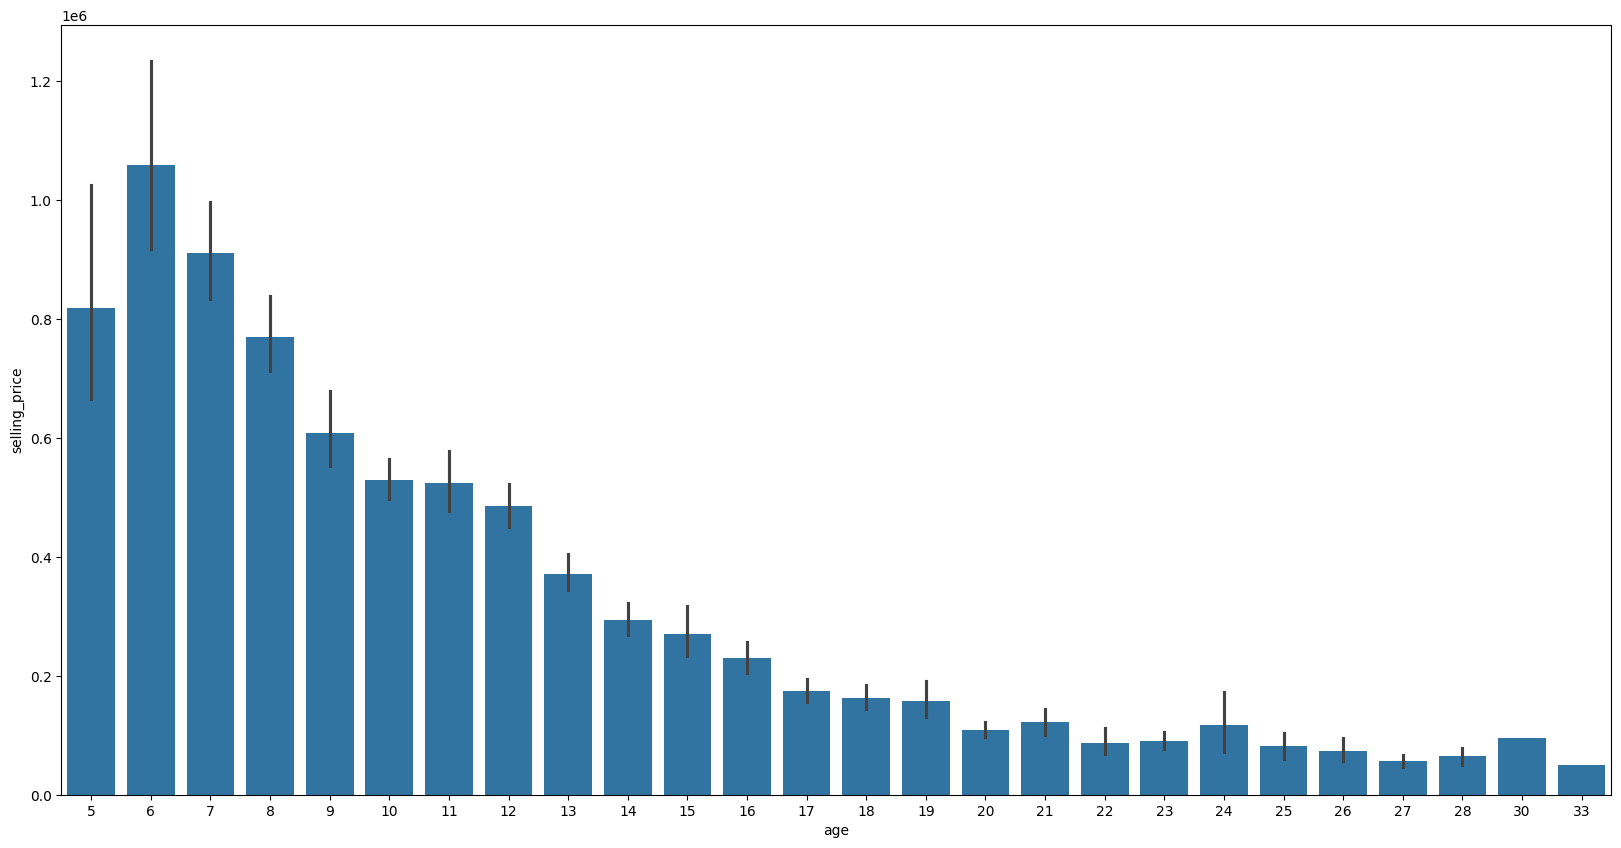

In [54]:
plt.figure(figsize=(20, 10))
sns.barplot(data=df_encoded, x='age', y='selling_price')
plt.show()

# Non Linear models

In [70]:
!pip install xgboost

In [71]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Train, Test split

In [56]:
X = df_encoded.drop(['selling_price', 'name'], axis=1)
y = df_encoded['selling_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest

In [57]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

In [61]:
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [66]:
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)

Random Forest RMSE: 182296.23854638403
Random Forest MAE: 110286.10317070286


# Gradient Boosting

In [64]:
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

In [65]:
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

In [67]:
gbr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
gbr_mae = mean_absolute_error(y_test, y_pred_gbr)

print("GBR RMSE:", gbr_rmse)
print("GBR MAE:", gbr_mae)

GBR RMSE: 187155.18042588446
GBR MAE: 122735.76436914348


# XGBoost

In [72]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist"   # fast training
)

In [73]:
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [74]:
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAE:", xgb_mae)

XGBoost RMSE: 174891.91249454618
XGBoost MAE: 109300.1875
